## Demo Lab : Exploratory Data Analysis

In this lab/demo  you will import the Iris data set and perform exploratory data analysis.

To complete this lab you will utilize JupyterLite running on the Cloud in Skills Network Labs environment. To launch the lab notebook in a new browser tab check the box below and click on the "Launch App" button. 
<BR><BR>

### Introduction
We will be using the iris data set for this tutorial. This is a well-known data set containing iris species and sepal and petal measurements. The data we will use are in a file called `iris_data.csv` found in the [data](data/) directory.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



#### **Question 1**
Load the data from the file using the techniques learned today. Examine it.

Determine the following:

* The number of data points (rows). (*Hint:* check out the dataframe `.shape` attribute.)
* The column names. (*Hint:* check out the dataframe `.columns` attribute.)
* The data types for each column. (*Hint:* check out the dataframe `.dtypes` attribute.)

In [2]:
data = pd.read_csv("data/iris_data.csv")
 
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
print(f"number of rows/columns: {data.shape}\n")
print(f"column names: {data.columns.tolist()}\n")
print(f"data types: \n{data.dtypes}\n")

number of rows/columns: (150, 5)

column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

data types: 
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object



#### **Question 2**
Examine the species names and note that they all begin with 'Iris-'. Remove this portion of the name so the species name is shorter. 

In [4]:
data['species'] = data.species.str.replace('Iris-', '')
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


#### **Question 3**

Determine the following:  
* The number of each species present. (*Hint:* check out the series `.value_counts` method.)
* The mean, median, and quantiles and ranges (max-min) for each petal and sepal measurement.

*Hint:* for the last question, the `.describe` method does have median, but it's not called median. It's the *50%* quantile. `.describe` does not have range though, and in order to get the range, you will need to create a new entry in the `.describe` table, which is `max - min`.

In [5]:
print(f"Number of each species: {data['species'].value_counts()}\n\n")

df_stats = data.describe()
df_stats.loc['range'] = df_stats.loc['max'] - df_stats.loc['min']
df_stats = df_stats.loc[['mean','25%','50%','75%','range']]
df_stats.rename({'50%':'median'}, inplace=True)
print(f"Data Statistics: \n {df_stats}")

Number of each species: species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


Data Statistics: 
         sepal_length  sepal_width  petal_length  petal_width
mean        5.843333        3.054      3.758667     1.198667
25%         5.100000        2.800      1.600000     0.300000
median      5.800000        3.000      4.350000     1.300000
75%         6.400000        3.300      5.100000     1.800000
range       3.600000        2.400      5.900000     2.400000


#### **Question 4**

Calculate the following **for each species** in a separate dataframe:

* The mean of each measurement (sepal_length, sepal_width, petal_length, and petal_width).
* The median of each of these measurements.

*Hint:* you may want to use Pandas [`groupby` method](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.groupby.html) to group by species before calculating the statistic.

If you finish both of these, try calculating both statistics (mean and median) in a single table (i.e. with a single groupby call). See the section of the Pandas documentation on [applying multiple functions at once](http://pandas.pydata.org/pandas-docs/stable/groupby.html#applying-multiple-functions-at-once) for a hint.

In [6]:
print(f"Mean value of attributes by species:\n {data.groupby('species').mean()}\n\n")
print(f"Median value of attributes by species:\n {data.groupby('species').median()}\n\n")


Mean value of attributes by species:
             sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.418         1.464        0.244
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026


Median value of attributes by species:
             sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa               5.0          3.4          1.50          0.2
versicolor           5.9          2.8          4.35          1.3
virginica            6.5          3.0          5.55          2.0




#### **Question 5**

Make a scatter plot of `sepal_length` vs `sepal_width` using Matplotlib. Label the axes and give the plot a title.

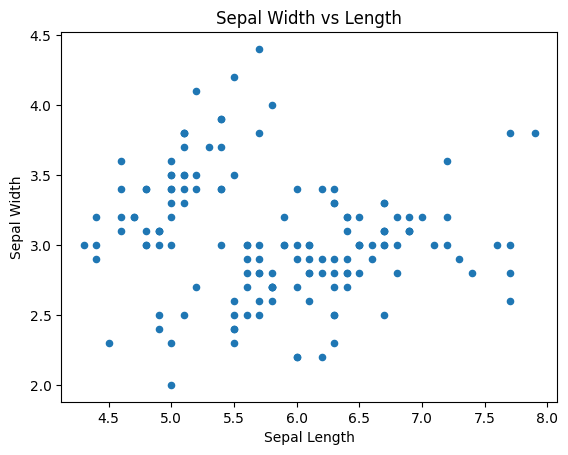

In [7]:
x = data.plot(kind='scatter', x='sepal_length', y='sepal_width', xlabel="Sepal Length", ylabel="Sepal Width", title="Sepal Width vs Length")

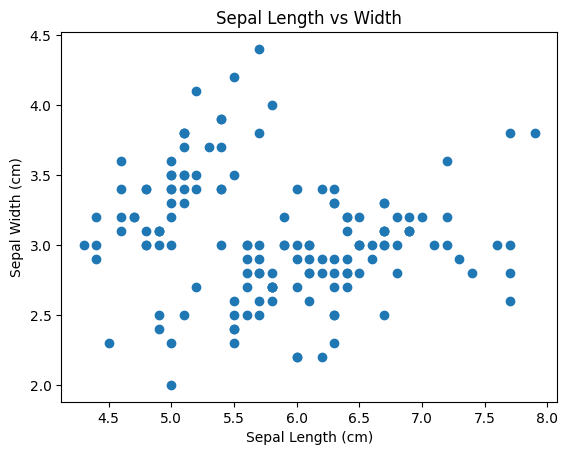

In [8]:
ax = plt.axes()
ax.scatter(data.sepal_length, data.sepal_width)
# Label the axes
ax.set(xlabel='Sepal Length (cm)',
       ylabel='Sepal Width (cm)',
       title='Sepal Length vs Width');

#### **Question 6**

Make a histogram of any one of the four features. Label axes and title it as appropriate. 

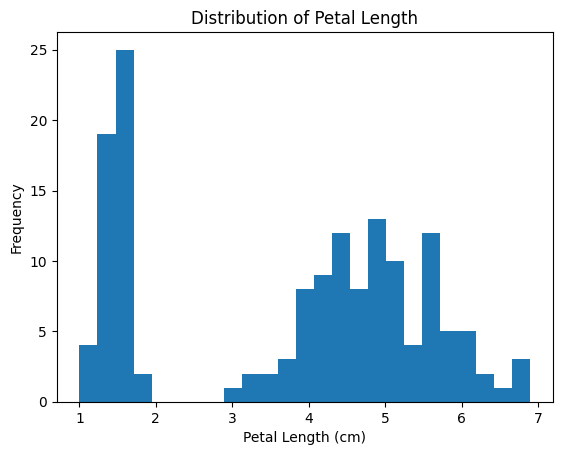

In [9]:
ax = plt.axes()
ax.hist(x=data['petal_length'], bins=25)
# Label the axes
ax.set(xlabel='Petal Length (cm)',
       ylabel='Frequency',
       title='Distribution of Petal Length');

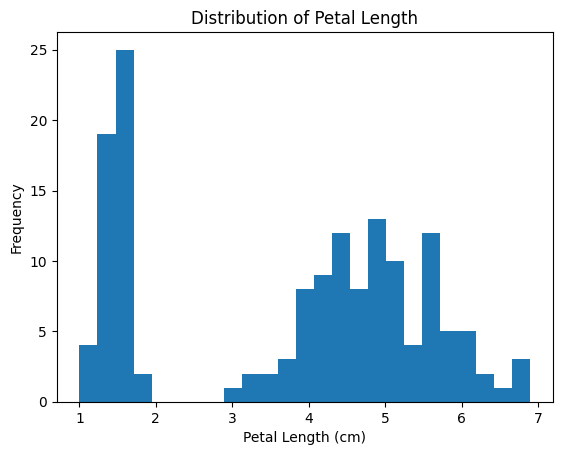

In [10]:
# alternatively
ax = data['petal_length'].plot(kind='hist', bins=25, xlabel="Petal Length (cm)", ylabel="Frequency", title="Distribution of Petal Length")

#### **Question 7**

Now create a single plot with histograms for each feature (`petal_width`, `petal_length`, `sepal_width`, `sepal_length`) overlayed. If you have time, next try to create four individual histogram plots in a single figure, where each plot contains one feature.

For some hints on how to do this with Pandas plotting methods, check out the [visualization guide](http://pandas.pydata.org/pandas-docs/version/0.18.1/visualization.html) for Pandas.

Text(0.5, 0, 'Size (cm)')

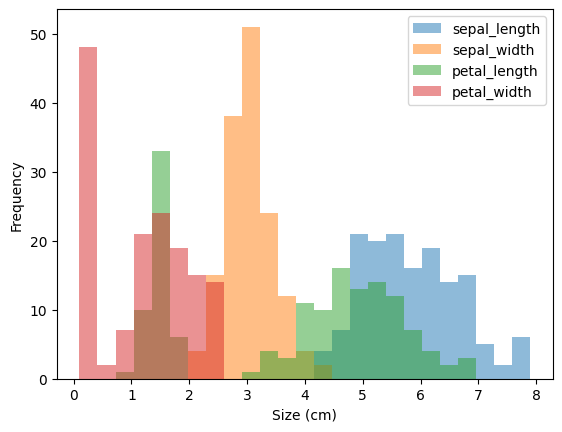

In [11]:
# This uses the `.plot.hist` method
ax = data.plot.hist(bins=25, alpha=0.5)
ax.set_xlabel('Size (cm)')

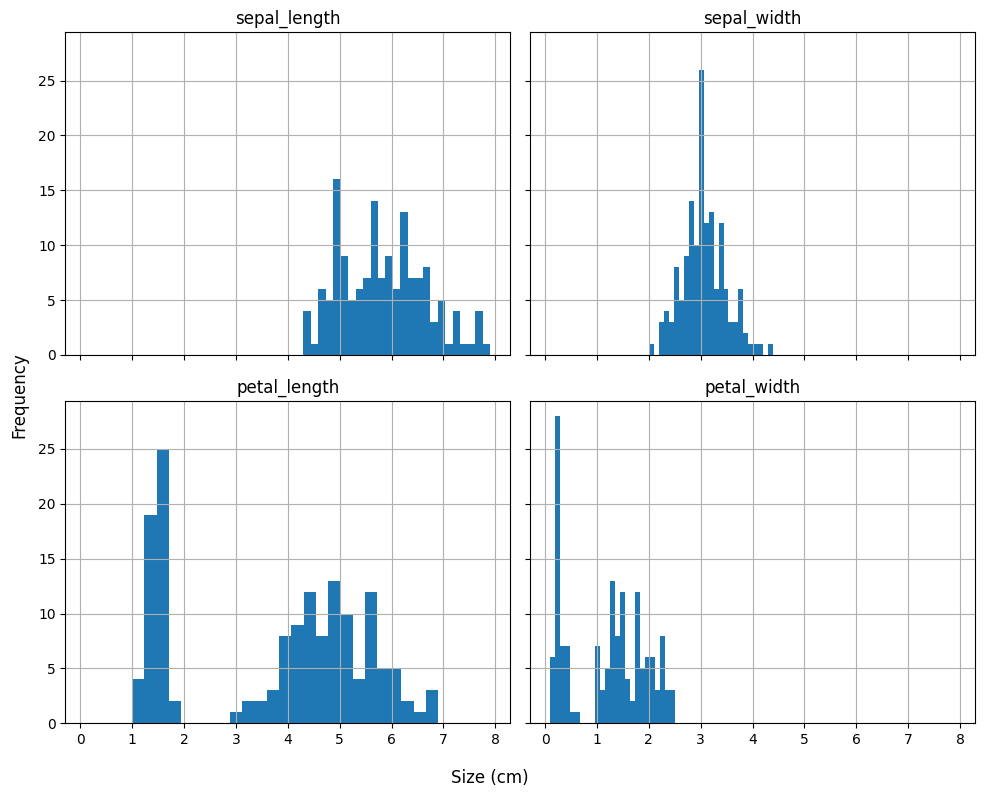

In [12]:
# To create four separate plots, use Pandas `.hist` method
axes = data.hist(bins=25, sharex=True, sharey=True, figsize=(10, 8))
fig = axes[0,0].get_figure()
fig.supxlabel('Size (cm)')
fig.supylabel('Frequency')
plt.tight_layout()


#### **Question 8**

Using Pandas, make a boxplot of each petal and sepal measurement. Here is the documentation for [Pandas boxplot method](http://pandas.pydata.org/pandas-docs/version/0.18.1/visualization.html#visualization-box).

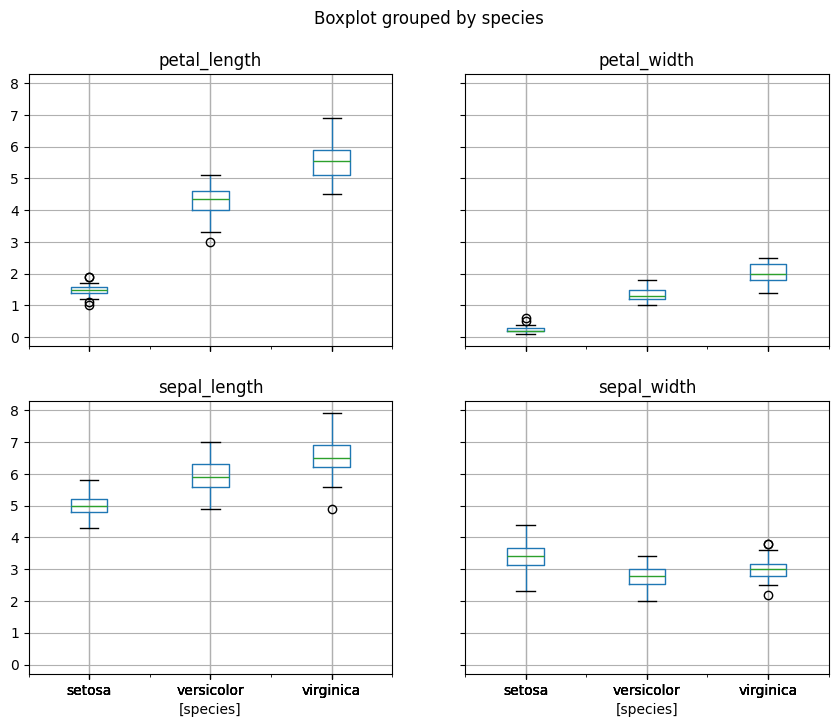

In [13]:
ax = data.boxplot(by='species', figsize=(10,8))

#### **Question 9**

Now make a single boxplot where the features are separated in the x-axis and species are colored with different hues. 

*Hint:* you may want to check the documentation for [Seaborn boxplots](http://seaborn.pydata.org/generated/seaborn.boxplot.html). 

Also note that Seaborn is very picky about data format--for this plot to work, the input dataframe will need to be manipulated so that each row contains a single data point (a species, a measurement type, and the measurement value). Check out Pandas [stack](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.stack.html) method as a starting place.

Here is an example of a data format that will work:

|   | species | measurement  | size |
| - | ------- | ------------ | ---- |
| 0	| setosa  | sepal_length | 5.1  |
| 1	| setosa  | sepal_width  | 3.5  |


In [14]:
plot_data = data.set_index('species').stack().to_frame().reset_index().rename(columns={0:'size', 'level_1':'measurement'})
plot_data.head()

,species,measurement,size
0,setosa,sepal_length,5.1
1,setosa,sepal_width,3.5
2,setosa,petal_length,1.4
3,setosa,petal_width,0.2
4,setosa,sepal_length,4.9


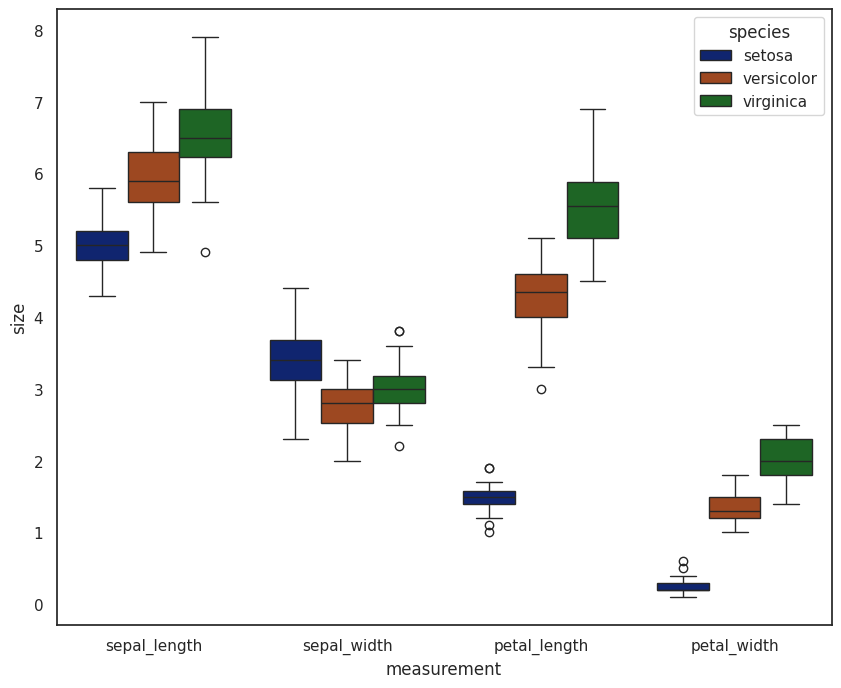

In [15]:
sns.set_style('white')
sns.set_context('notebook')
sns.set_palette('dark')

f = plt.figure(figsize=(10,8))
sns.boxplot(data=plot_data, x='measurement', y='size', hue='species');

#### **Question 10**

Make a [pairplot](http://seaborn.pydata.org/generated/seaborn.pairplot.html) with Seaborn to examine the correlation between each of the measurements.

*Hint:* this plot may look complicated, but it is actually only a single line of code. This is the power of Seaborn and dataframe-aware plotting! See the lecture notes for reference.

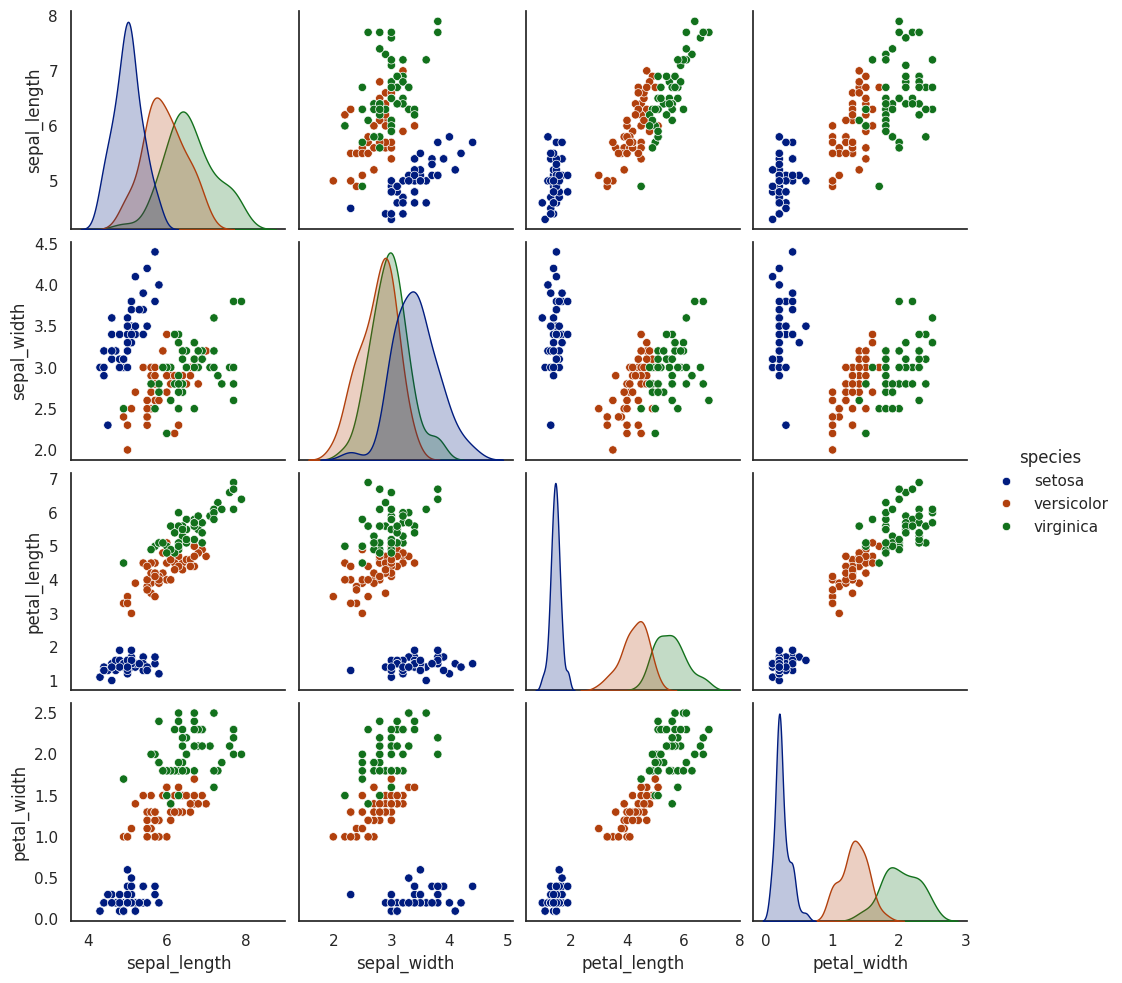

In [16]:
sns.set_context('notebook')
sns.pairplot(data, hue='species');